Loading data...
Total responses loaded: 96

Columns in dataset:
['Timestamp', 'Do you consent to participate in this research?', 'Click Submit below to finish', 'Community relation (select one)', 'Age band', 'Current status (select all that apply)', 'Primary job/internship search channels used in the last 12 months (select all that apply)', 'Country/region of usual residence', 'State(if India)', 'Highest education level completed', 'Current monthly personal income (approx.)', 'Household financial situation', 'Before today, how familiar were you with the idea of job scams?', 'In the past 12 months, have you personally encountered any suspicious job/internship offers or tasks?', 'Where do you usually come across job/internship opportunities? (select all that apply)', 'How confident are you that you can recognize a job scam when you see one?', 'How did the opportunity first reach you?', 'What was being offered? (select all that apply)', 'Which elements did you notice? (select all that app

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu



Analyzing sentiment in narratives...
Analyzing emotions in narratives...

Sentiment and emotion analysis complete!

RESULTS: EMOTION DISTRIBUTION

  Emotion  Count  Percentage
    fear     13        37.1
surprise      6        17.1
 sadness      5        14.3
 neutral      4        11.4
     joy      4        11.4
   anger      3         8.6

RESULTS: EMOTION VS OUTCOMES

                Avg_Amount  Median_Amount  N_Responses  Reporting_Rate  Reporting_Rate_Pct
emotion_label                                                                            
anger                0.00            0.0            1            0.00                 0.0
fear                 0.00            0.0            5            0.15                15.0
joy                   NaN            NaN            0            0.25                25.0
neutral          10000.00            0.0            3            0.00                 0.0
sadness              0.00            0.0            2            0.00              

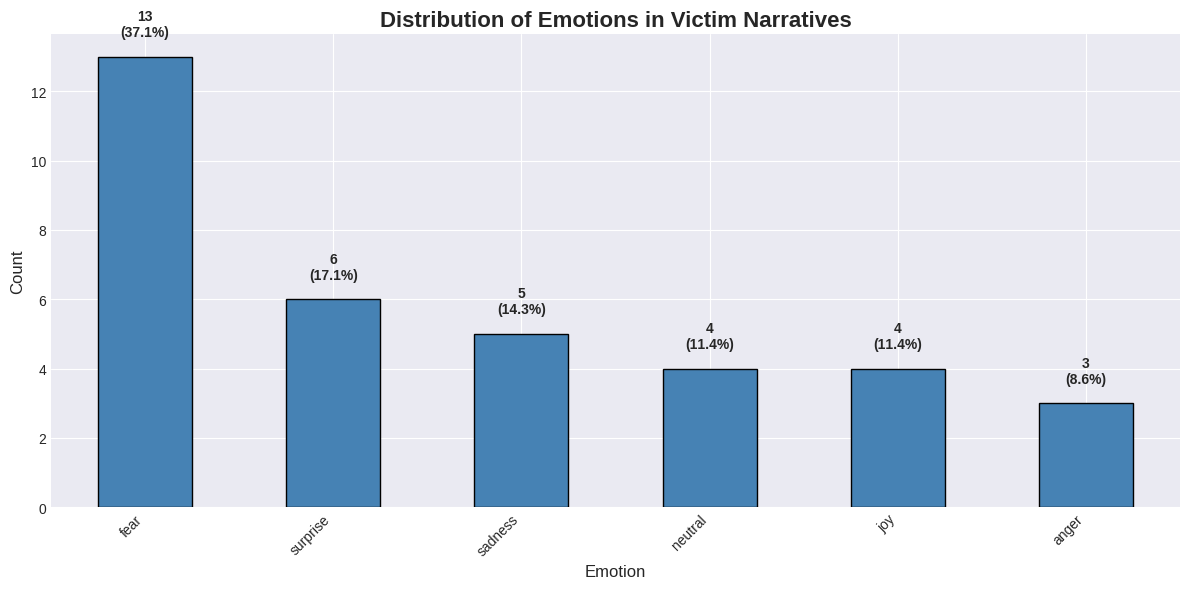


✓ Figure 1: Emotion Distribution displayed


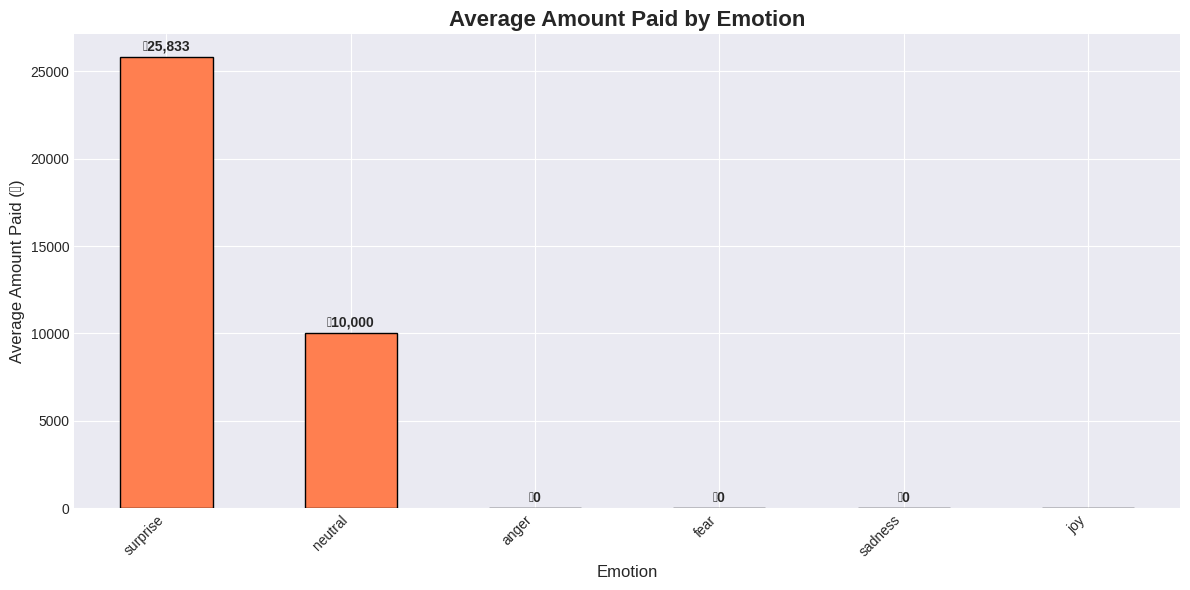

✓ Figure 2: Emotion vs Amount Paid displayed


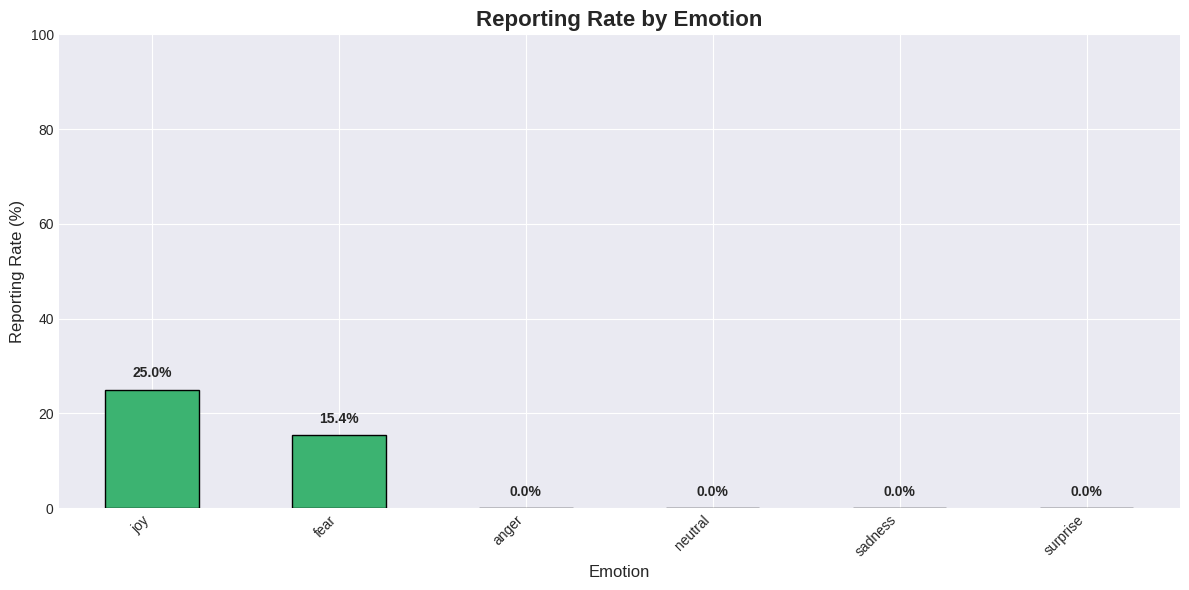

✓ Figure 3: Emotion vs Reporting Rate displayed


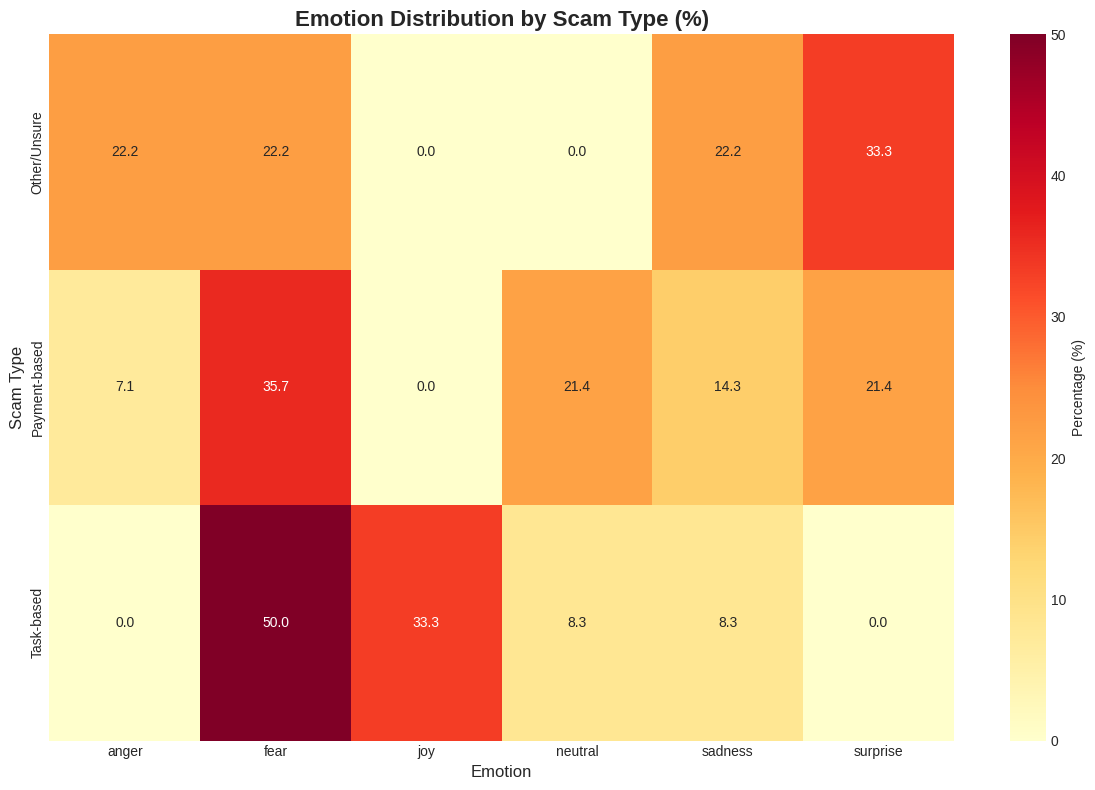

✓ Figure 4: Emotion by Scam Type Heatmap displayed

FINAL SUMMARY OUTPUT

PROCESSED DATA PREVIEW (First 10 rows)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [ ]:
"""
Job Scams Survey - Sentiment and Emotion Analysis
Analyzes emotional tone of victim narratives and correlates with outcomes
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import torch
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency
from scipy.stats import false_discovery_control
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Loading data...")
# Load the survey responses
df = pd.read_excel('responses.xlsx')

print(f"Total responses loaded: {len(df)}")
print("\nColumns in dataset:")
print(df.columns.tolist())

# ============================================================================
# STEP 1: IDENTIFY AND PREPARE TEXT COLUMNS
# ============================================================================

# Based on the form, text fields for narrative analysis are:
# 1. "Share Your Experience (Optional)" - at end of C1 (Payment-based)
# 2. "Share Your Experience (Optional)" - at end of C2 (Task-based)
# 3. "Share Your Experience (Other/Unsure)" - in Section Z
# 4. "When you realized it might be suspicious or fraudulent, what stopped you from stopping earlier?" - Section D

# Identify the actual column names (they might have timestamps)
text_columns = []
for col in df.columns:
    col_lower = col.lower()
    if ('share your experience' in col_lower or
        'stopped you from stopping earlier' in col_lower or
        'describe your experience' in col_lower):
        text_columns.append(col)

print(f"\nIdentified text columns for analysis:")
for col in text_columns:
    print(f"  - {col}")

# Combine all text narratives into one field
df['combined_narrative'] = df[text_columns].fillna('').agg(' '.join, axis=1)
df['narrative_length'] = df['combined_narrative'].str.len()

# Filter to responses with meaningful text (at least 10 characters)
df_with_text = df[df['narrative_length'] >= 10].copy()
print(f"\nResponses with meaningful text narratives: {len(df_with_text)}")

# ============================================================================
# STEP 2: EXTRACT KEY VARIABLES FOR ANALYSIS
# ============================================================================

# Amount paid - find the column
amount_cols = [col for col in df.columns if 'total amount paid' in col.lower()]
if amount_cols:
    amount_col = amount_cols[0]
    print(f"\nAmount column: {amount_col}")

    # Convert to numeric values (midpoint of ranges)
    amount_mapping = {
        'Less than ₹500': 250,
        '₹500–₹1,999': 1250,
        '₹2,000–₹4,999': 3500,
        '₹5,000–₹9,999': 7500,
        '₹10,000–₹49,999': 30000,
        '₹50,000+': 75000,
        'I did not pay': 0,
        'Prefer not to say': np.nan
    }

    df_with_text['amount_paid_numeric'] = df_with_text[amount_col].map(amount_mapping)
else:
    print("Warning: Amount paid column not found")
    df_with_text['amount_paid_numeric'] = np.nan

# Reporting status - find the column
report_cols = [col for col in df.columns if 'did you report' in col.lower()]
if report_cols:
    report_col = report_cols[0]
    print(f"Reporting column: {report_col}")
    df_with_text['reported_fraud'] = (df_with_text[report_col] == 'Yes').astype(int)
else:
    print("Warning: Reporting column not found")
    df_with_text['reported_fraud'] = np.nan

# Scam type - find the column
type_cols = [col for col in df.columns if 'which best describes' in col.lower()]
if type_cols:
    type_col = type_cols[0]
    print(f"Scam type column: {type_col}")
    df_with_text['scam_type'] = df_with_text[type_col].apply(
        lambda x: 'Payment-based' if 'payment' in str(x).lower()
        else ('Task-based' if 'task' in str(x).lower() else 'Other/Unsure')
    )
else:
    print("Warning: Scam type column not found")
    df_with_text['scam_type'] = 'Unknown'

print(f"\nData preparation complete. Analyzing {len(df_with_text)} narratives...")

# ============================================================================
# STEP 3: SENTIMENT ANALYSIS
# ============================================================================

print("\nInitializing sentiment analysis models...")
print("(This may take a few minutes on first run to download models)")

# Initialize sentiment analyzer
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)

# Initialize emotion analyzer
emotion_analyzer = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    device=0 if torch.cuda.is_available() else -1
)

def get_sentiment(text):
    """Extract sentiment from text"""
    if pd.isna(text) or len(str(text).strip()) < 10:
        return {'label': 'NEUTRAL', 'score': 0.5}
    text_truncated = str(text)[:512]
    try:
        result = sentiment_analyzer(text_truncated)[0]
        return result
    except:
        return {'label': 'NEUTRAL', 'score': 0.5}

def get_emotion(text):
    """Extract emotion from text"""
    if pd.isna(text) or len(str(text).strip()) < 10:
        return {'label': 'neutral', 'score': 0.0}
    text_truncated = str(text)[:512]
    try:
        result = emotion_analyzer(text_truncated)[0]
        return result
    except:
        return {'label': 'neutral', 'score': 0.0}

print("\nAnalyzing sentiment in narratives...")
df_with_text['sentiment'] = df_with_text['combined_narrative'].apply(get_sentiment)
df_with_text['sentiment_label'] = df_with_text['sentiment'].apply(lambda x: x['label'])
df_with_text['sentiment_score'] = df_with_text['sentiment'].apply(lambda x: x['score'])

print("Analyzing emotions in narratives...")
df_with_text['emotion'] = df_with_text['combined_narrative'].apply(get_emotion)
df_with_text['emotion_label'] = df_with_text['emotion'].apply(lambda x: x['label'])
df_with_text['emotion_score'] = df_with_text['emotion'].apply(lambda x: x['score'])

print("\nSentiment and emotion analysis complete!")

# ============================================================================
# STEP 4: DESCRIPTIVE STATISTICS
# ============================================================================

print("\n" + "="*80)
print("RESULTS: EMOTION DISTRIBUTION")
print("="*80)

emotion_counts = df_with_text['emotion_label'].value_counts()
emotion_percentages = (emotion_counts / len(df_with_text) * 100).round(1)

results_table = pd.DataFrame({
    'Emotion': emotion_counts.index,
    'Count': emotion_counts.values,
    'Percentage': emotion_percentages.values
})
print("\n", results_table.to_string(index=False))

# ============================================================================
# STEP 5: EMOTION VS OUTCOMES
# ============================================================================

print("\n" + "="*80)
print("RESULTS: EMOTION VS OUTCOMES")
print("="*80)

# Calculate aggregated statistics by emotion
emotion_outcomes = df_with_text.groupby('emotion_label').agg({
    'amount_paid_numeric': ['mean', 'median', 'count'],
    'reported_fraud': 'mean'
}).round(2)

emotion_outcomes.columns = ['Avg_Amount', 'Median_Amount', 'N_Responses', 'Reporting_Rate']
emotion_outcomes['Reporting_Rate_Pct'] = (emotion_outcomes['Reporting_Rate'] * 100).round(1)

print("\n", emotion_outcomes.to_string())

# ============================================================================
# STEP 6: STATISTICAL TESTS
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

# Test 1: Kruskal-Wallis test for amount paid across emotions
print("\n1. Testing if emotion predicts amount paid (Kruskal-Wallis H-test):")
emotions_with_data = df_with_text.groupby('emotion_label')['amount_paid_numeric'].count()
emotions_to_test = emotions_with_data[emotions_with_data >= 5].index.tolist()

if len(emotions_to_test) >= 2:
    groups = [df_with_text[df_with_text['emotion_label'] == emotion]['amount_paid_numeric'].dropna()
              for emotion in emotions_to_test]

    # Only test if we have at least 2 groups with data
    groups_with_data = [g for g in groups if len(g) > 0]

    if len(groups_with_data) >= 2:
        h_stat, p_value = kruskal(*groups_with_data)
        print(f"   H-statistic = {h_stat:.2f}, p-value = {p_value:.4f}")

        if p_value < 0.05:
            print("   *** Significant difference found (p < 0.05)")

            # Post-hoc pairwise comparisons
            print("\n   Post-hoc pairwise comparisons (Mann-Whitney U tests):")
            p_values = []
            comparisons = []

            for i in range(len(emotions_to_test)):
                for j in range(i+1, len(emotions_to_test)):
                    g1 = df_with_text[df_with_text['emotion_label'] == emotions_to_test[i]]['amount_paid_numeric'].dropna()
                    g2 = df_with_text[df_with_text['emotion_label'] == emotions_to_test[j]]['amount_paid_numeric'].dropna()

                    if len(g1) >= 3 and len(g2) >= 3:
                        u_stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
                        p_values.append(p)
                        comparisons.append(f"{emotions_to_test[i]} vs {emotions_to_test[j]}")

            if p_values:
                # FDR correction
                p_adjusted = false_discovery_control(p_values)
                for comp, p_raw, p_adj in zip(comparisons, p_values, p_adjusted):
                    sig_marker = "***" if p_adj < 0.05 else ""
                    print(f"   {comp}: p_raw={p_raw:.4f}, p_adj={p_adj:.4f} {sig_marker}")
        else:
            print("   No significant difference found")
    else:
        print("   Insufficient data for statistical test")
else:
    print("   Insufficient emotion categories for comparison")

# Test 2: Chi-square test for reporting rate across emotions
print("\n2. Testing if emotion predicts reporting behavior (Chi-square test):")
contingency_data = df_with_text.groupby(['emotion_label', 'reported_fraud']).size().unstack(fill_value=0)

if contingency_data.shape[0] >= 2 and contingency_data.shape[1] >= 2:
    chi2, p_value, dof, expected = chi2_contingency(contingency_data)
    print(f"   Chi-square = {chi2:.2f}, p-value = {p_value:.4f}, df = {dof}")

    if p_value < 0.05:
        print("   *** Significant association found (p < 0.05)")
    else:
        print("   No significant association found")
else:
    print("   Insufficient data for chi-square test")

# Test 3: Emotion vs Scam Type
print("\n3. Emotion distribution across scam types:")
emotion_by_type = pd.crosstab(
    df_with_text['scam_type'],
    df_with_text['emotion_label'],
    normalize='index'
) * 100
print("\n", emotion_by_type.round(1).to_string())

# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Figure 1: Emotion Distribution
plt.figure(figsize=(12, 6))
ax = emotion_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Emotions in Victim Narratives', fontsize=16, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add percentage labels on bars
for i, (count, pct) in enumerate(zip(emotion_counts.values, emotion_percentages.values)):
    ax.text(i, count + 0.5, f'{count}\n({pct}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print("\n✓ Figure 1: Emotion Distribution displayed")

# Figure 2: Emotion vs Amount Paid
plt.figure(figsize=(12, 6))
emotion_amount = df_with_text.groupby('emotion_label')['amount_paid_numeric'].mean().sort_values(ascending=False)
ax = emotion_amount.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Amount Paid by Emotion', fontsize=16, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Average Amount Paid (₹)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, val in enumerate(emotion_amount.values):
    if not np.isnan(val):
        ax.text(i, val + 200, f'₹{val:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Figure 2: Emotion vs Amount Paid displayed")

# Figure 3: Emotion vs Reporting Rate
plt.figure(figsize=(12, 6))
emotion_reporting = df_with_text.groupby('emotion_label')['reported_fraud'].mean().sort_values(ascending=False) * 100
ax = emotion_reporting.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Reporting Rate by Emotion', fontsize=16, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Reporting Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

# Add percentage labels
for i, val in enumerate(emotion_reporting.values):
    if not np.isnan(val):
        ax.text(i, val + 2, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Figure 3: Emotion vs Reporting Rate displayed")

# Figure 4: Emotion Heatmap by Scam Type
plt.figure(figsize=(12, 8))
sns.heatmap(emotion_by_type, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Percentage (%)'})
plt.title('Emotion Distribution by Scam Type (%)', fontsize=16, fontweight='bold')
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Scam Type', fontsize=12)
plt.tight_layout()
plt.show()
print("✓ Figure 4: Emotion by Scam Type Heatmap displayed")

# ============================================================================
# STEP 8: FINAL SUMMARY OUTPUT
# ============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY OUTPUT")
print("="*80)

print("\n" + "="*80)
print("PROCESSED DATA PREVIEW (First 10 rows)")
print("="*80)

# Display processed data
output_df = df_with_text[[
    'combined_narrative', 'narrative_length',
    'sentiment_label', 'sentiment_score',
    'emotion_label', 'emotion_score',
    'amount_paid_numeric', 'reported_fraud', 'scam_type'
]].copy()

print("\n", output_df.head(10).to_string())

print("\n" + "="*80)
print("COMPLETE ANALYSIS SUMMARY")
print("="*80)

print(f"\nTotal responses analyzed: {len(df_with_text)}")

print("\n" + "-"*80)
print("EMOTION DISTRIBUTION:")
print("-"*80)
print("\n", results_table.to_string(index=False))

print("\n" + "-"*80)
print("EMOTION VS OUTCOMES:")
print("-"*80)
print("\n", emotion_outcomes.to_string())

print("\n" + "-"*80)
print("KEY FINDINGS:")
print("-"*80)
print(f"• Most common emotion: {emotion_counts.index[0]} ({emotion_percentages.values[0]}%)")

if not emotion_amount.empty:
    highest_amount_emotion = emotion_amount.index[0]
    print(f"• Emotion with highest average payment: {highest_amount_emotion} (₹{emotion_amount.values[0]:,.0f})")

if not emotion_reporting.empty:
    highest_reporting_emotion = emotion_reporting.index[0]
    print(f"• Emotion with highest reporting rate: {highest_reporting_emotion} ({emotion_reporting.values[0]:.1f}%)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nAll visualizations have been displayed.")
print("All results are shown in the console output above.")